# Historical Warehouse Data Generation

Generate a larger synthetic warehouse order history to create a realistic foundation for demand forecasting, machine learning, and future digital twin simulations.

## 1. Setup

Import the libraries required for data generation and manipulation.

In [24]:
import pandas as pd
import numpy as np

## 2. Historical Time Period

Define the time range used to generate historical warehouse demand.  
A full year of daily data provides enough history to later analyze trends, weekly patterns, and seasonality.

In [25]:
start_date = "2025-01-01"
end_date = "2025-12-31"

dates = pd.date_range(
    start=start_date,
    end=end_date,
    freq="D"
)

dates

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=365, freq='D')

## 3. Product Demand Profiles

Load the warehouse product catalog and assign a base daily demand rate to each product.

These base demand values represent the average expected daily demand before adding effects such as weekends, seasonality, trends, and random variation.

In [26]:
products = pd.read_csv("../data/products.csv")

products

,product_id,product_name,category,unit_price,weight_kg
0,P001,Laptop,Electronics,850,1.8
1,P002,Wireless Mouse,Electronics,25,0.1
2,P003,Mechanical Keyboard,Electronics,70,0.8
3,P004,Office Chair,Furniture,180,12.5
4,P005,Desk Lamp,Home,35,1.2
5,P006,Monitor 27 inch,Electronics,300,5.5
6,P007,Standing Desk,Furniture,450,28.0
7,P008,USB-C Hub,Electronics,45,0.2
8,P009,Storage Box,Home,20,2.0
9,P010,Headphones,Electronics,90,0.3


In [27]:
base_demand = {
    "P001": 4,
    "P002": 12,
    "P003": 7,
    "P004": 3,
    "P005": 6,
    "P006": 5,
    "P007": 2,
    "P008": 9,
    "P009": 4,
    "P010": 8
}

products["base_daily_demand"] = products["product_id"].map(base_demand)

products[
    ["product_id", "product_name", "base_daily_demand"]
]

,product_id,product_name,base_daily_demand
0,P001,Laptop,4
1,P002,Wireless Mouse,12
2,P003,Mechanical Keyboard,7
3,P004,Office Chair,3
4,P005,Desk Lamp,6
5,P006,Monitor 27 inch,5
6,P007,Standing Desk,2
7,P008,USB-C Hub,9
8,P009,Storage Box,4
9,P010,Headphones,8


## 4. Product-Date Grid

Create a complete grid containing one row for every product on every day of the historical period.

This structure will serve as the foundation for generating daily demand for each product.

In [28]:
product_daily = (
    products.assign(key=1)
    .merge(pd.DataFrame({"date": dates, "key": 1}), on="key")
    .drop("key", axis=1)
)

product_daily.head()

,product_id,product_name,category,unit_price,weight_kg,base_daily_demand,date
0,P001,Laptop,Electronics,850,1.8,4,2025-01-01
1,P001,Laptop,Electronics,850,1.8,4,2025-01-02
2,P001,Laptop,Electronics,850,1.8,4,2025-01-03
3,P001,Laptop,Electronics,850,1.8,4,2025-01-04
4,P001,Laptop,Electronics,850,1.8,4,2025-01-05


In [29]:
product_daily.shape

(3650, 7)

## 5. Weekly Demand Pattern

Introduce weekly demand patterns by adjusting product demand according to the day of the week.

This creates a more realistic time series where demand varies systematically between weekdays and weekends.

In [30]:
product_daily["day_of_week"] = product_daily["date"].dt.day_name()

product_daily[
    ["date", "day_of_week"]
].head(10)

,date,day_of_week
0,2025-01-01,Wednesday
1,2025-01-02,Thursday
2,2025-01-03,Friday
3,2025-01-04,Saturday
4,2025-01-05,Sunday
5,2025-01-06,Monday
6,2025-01-07,Tuesday
7,2025-01-08,Wednesday
8,2025-01-09,Thursday
9,2025-01-10,Friday


In [31]:
weekly_factors = {
    "Monday": 1.00,
    "Tuesday": 1.00,
    "Wednesday": 1.00,
    "Thursday": 1.05,
    "Friday": 1.15,
    "Saturday": 0.85,
    "Sunday": 0.70
}

In [32]:
product_daily["weekly_factor"] = (
    product_daily["day_of_week"].map(weekly_factors)
)

In [33]:
product_daily[
    ["date", "day_of_week", "weekly_factor"]
].head(10)

,date,day_of_week,weekly_factor
0,2025-01-01,Wednesday,1.00
1,2025-01-02,Thursday,1.05
2,2025-01-03,Friday,1.15
3,2025-01-04,Saturday,0.85
4,2025-01-05,Sunday,0.70
5,2025-01-06,Monday,1.00
6,2025-01-07,Tuesday,1.00
7,2025-01-08,Wednesday,1.00
8,2025-01-09,Thursday,1.05
9,2025-01-10,Friday,1.15


## 6. Monthly Seasonality

Introduce monthly seasonal effects to simulate changes in warehouse demand throughout the year.

Seasonal factors are synthetic assumptions used to create structured demand patterns for later forecasting experiments.

In [34]:
product_daily["month"] = product_daily["date"].dt.month

product_daily[
    ["date", "month"]
].head()

,date,month
0,2025-01-01,1
1,2025-01-02,1
2,2025-01-03,1
3,2025-01-04,1
4,2025-01-05,1


### Monthly Seasonal Factors

Assign a demand multiplier to each month to simulate seasonal variations in customer demand.

In [35]:
monthly_factors = {
    1: 0.90,
    2: 0.90,
    3: 0.95,
    4: 1.00,
    5: 1.00,
    6: 1.05,
    7: 1.00,
    8: 0.95,
    9: 1.05,
    10: 1.10,
    11: 1.25,
    12: 1.35
}

In [36]:
product_daily["monthly_factor"] = (
    product_daily["month"].map(monthly_factors)
)

In [37]:
product_daily[
    [
        "date",
        "day_of_week",
        "weekly_factor",
        "month",
        "monthly_factor"
    ]
].head()

,date,day_of_week,weekly_factor,month,monthly_factor
0,2025-01-01,Wednesday,1.00,1,0.9
1,2025-01-02,Thursday,1.05,1,0.9
2,2025-01-03,Friday,1.15,1,0.9
3,2025-01-04,Saturday,0.85,1,0.9
4,2025-01-05,Sunday,0.70,1,0.9


## 7. Demand Trend

Introduce a gradual demand trend over time to simulate long-term growth in warehouse demand.

Unlike seasonality, which represents repeating patterns, a trend represents a persistent increase or decrease over time.

In [38]:
product_daily["days_since_start"] = (
    product_daily["date"] - product_daily["date"].min()
).dt.days

product_daily[
    ["date", "days_since_start"]
].head()

,date,days_since_start
0,2025-01-01,0
1,2025-01-02,1
2,2025-01-03,2
3,2025-01-04,3
4,2025-01-05,4


### Trend Factor

Apply a gradual synthetic growth factor to simulate increasing demand over the historical period.

In [39]:
product_daily["trend_factor"] = (
    1 + 0.20 * product_daily["days_since_start"] / 364
)

In [40]:
product_daily[
    ["date", "days_since_start", "trend_factor"]
].iloc[[0, 100, 200, 364]]

,date,days_since_start,trend_factor
0,2025-01-01,0,1.000000
100,2025-04-11,100,1.054945
200,2025-07-20,200,1.109890
364,2025-12-31,364,1.200000


## 8. Random Demand Variation

Add random variation to simulate the natural uncertainty found in real warehouse demand.

Even when expected demand is similar, actual daily demand can vary due to unpredictable customer behavior and other external factors.

In [41]:
np.random.seed(42)

In [42]:
np.random.normal(
    loc=1.0,
    scale=0.10,
    size=10
)

array([1.04967142, 0.98617357, 1.06476885, 1.15230299, 0.97658466,
       0.9765863 , 1.15792128, 1.07674347, 0.95305256, 1.054256  ])

In [43]:
product_daily["random_factor"] = np.random.normal(
    loc=1.0,
    scale=0.10,
    size=len(product_daily)
)

In [44]:
product_daily[
    ["date", "product_id", "random_factor"]
].head(10)

,date,product_id,random_factor
0,2025-01-01,P001,0.953658
1,2025-01-02,P001,0.953427
2,2025-01-03,P001,1.024196
3,2025-01-04,P001,0.808672
4,2025-01-05,P001,0.827508
5,2025-01-06,P001,0.943771
6,2025-01-07,P001,0.898717
7,2025-01-08,P001,1.031425
8,2025-01-09,P001,0.909198
9,2025-01-10,P001,0.858770


## 9. Expected Daily Demand

Calculate the expected daily demand by combining the base demand with weekly, seasonal, and trend effects.

Random variation will be applied afterward to transform expected demand into simulated actual demand.

In [45]:
product_daily["expected_demand"] = (
    product_daily["base_daily_demand"]
    * product_daily["weekly_factor"]
    * product_daily["monthly_factor"]
    * product_daily["trend_factor"]
)

In [46]:
product_daily[
    [
        "product_id",
        "date",
        "base_daily_demand",
        "weekly_factor",
        "monthly_factor",
        "trend_factor",
        "expected_demand"
    ]
].head(10)

,product_id,date,base_daily_demand,weekly_factor,monthly_factor,trend_factor,expected_demand
0,P001,2025-01-01,4,1.00,0.9,1.000000,3.600000
1,P001,2025-01-02,4,1.05,0.9,1.000549,3.782077
2,P001,2025-01-03,4,1.15,0.9,1.001099,4.144549
3,P001,2025-01-04,4,0.85,0.9,1.001648,3.065044
4,P001,2025-01-05,4,0.70,0.9,1.002198,2.525538
5,P001,2025-01-06,4,1.00,0.9,1.002747,3.609890
6,P001,2025-01-07,4,1.00,0.9,1.003297,3.611868
7,P001,2025-01-08,4,1.00,0.9,1.003846,3.613846
8,P001,2025-01-09,4,1.05,0.9,1.004396,3.796615
9,P001,2025-01-10,4,1.15,0.9,1.004945,4.160473


## 10. Simulated Actual Demand

Convert expected demand into simulated actual daily demand by applying random variation.

The resulting values are rounded to whole units because product demand represents discrete quantities.

In [47]:
product_daily["actual_demand"] = (
    product_daily["expected_demand"]
    * product_daily["random_factor"]
).round()

In [48]:
product_daily[
    [
        "product_id",
        "date",
        "expected_demand",
        "random_factor",
        "actual_demand"
    ]
].head(10)

,product_id,date,expected_demand,random_factor,actual_demand
0,P001,2025-01-01,3.600000,0.953658,3.0
1,P001,2025-01-02,3.782077,0.953427,4.0
2,P001,2025-01-03,4.144549,1.024196,4.0
3,P001,2025-01-04,3.065044,0.808672,2.0
4,P001,2025-01-05,2.525538,0.827508,2.0
5,P001,2025-01-06,3.609890,0.943771,3.0
6,P001,2025-01-07,3.611868,0.898717,3.0
7,P001,2025-01-08,3.613846,1.031425,4.0
8,P001,2025-01-09,3.796615,0.909198,3.0
9,P001,2025-01-10,4.160473,0.858770,4.0


In [49]:
product_daily["actual_demand"] = (
    product_daily["actual_demand"].astype(int)
)

In [50]:
product_daily[
    ["expected_demand", "random_factor", "actual_demand"]
].head(10)

,expected_demand,random_factor,actual_demand
0,3.600000,0.953658,3
1,3.782077,0.953427,4
2,4.144549,1.024196,4
3,3.065044,0.808672,2
4,2.525538,0.827508,2
5,3.609890,0.943771,3
6,3.611868,0.898717,3
7,3.613846,1.031425,4
8,3.796615,0.909198,3
9,4.160473,0.858770,4


## 11. Data Validation

Validate the generated historical demand data before saving it.

The validation checks the dataset size, missing values, and demand values to ensure the synthetic data is consistent and suitable for future analysis and forecasting.

In [51]:
product_daily.shape

(3650, 16)

In [52]:
product_daily.isnull().sum()

product_id           0
product_name         0
category             0
unit_price           0
weight_kg            0
base_daily_demand    0
date                 0
day_of_week          0
weekly_factor        0
month                0
monthly_factor       0
days_since_start     0
trend_factor         0
random_factor        0
expected_demand      0
actual_demand        0
dtype: int64

In [53]:
product_daily["actual_demand"].min()

np.int64(1)

In [54]:
product_daily["actual_demand"].max()

np.int64(25)

In [55]:
product_daily["actual_demand"].mean()

np.float64(6.67972602739726)

In [57]:
product_daily[product_daily["product_id"] == "P001"]

,product_id,product_name,category,unit_price,weight_kg,base_daily_demand,date,day_of_week,weekly_factor,month,monthly_factor,days_since_start,trend_factor,random_factor,expected_demand,actual_demand
0,P001,Laptop,Electronics,850,1.8,4,2025-01-01,Wednesday,1.00,1,0.90,0,1.000000,0.953658,3.600000,3
1,P001,Laptop,Electronics,850,1.8,4,2025-01-02,Thursday,1.05,1,0.90,1,1.000549,0.953427,3.782077,4
2,P001,Laptop,Electronics,850,1.8,4,2025-01-03,Friday,1.15,1,0.90,2,1.001099,1.024196,4.144549,4
3,P001,Laptop,Electronics,850,1.8,4,2025-01-04,Saturday,0.85,1,0.90,3,1.001648,0.808672,3.065044,2
4,P001,Laptop,Electronics,850,1.8,4,2025-01-05,Sunday,0.70,1,0.90,4,1.002198,0.827508,2.525538,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,P001,Laptop,Electronics,850,1.8,4,2025-12-27,Saturday,0.85,12,1.35,360,1.197802,1.002451,5.497912,6
361,P001,Laptop,Electronics,850,1.8,4,2025-12-28,Sunday,0.70,12,1.35,361,1.198352,1.049800,4.529769,5
362,P001,Laptop,Electronics,850,1.8,4,2025-12-29,Monday,1.00,12,1.35,362,1.198901,1.145114,6.474066,7
363,P001,Laptop,Electronics,850,1.8,4,2025-12-30,Tuesday,1.00,12,1.35,363,1.199451,1.095927,6.477033,7


In [71]:
p001_data = product_daily[
    product_daily["product_id"] == "P001"
].copy()

In [62]:
p001_data.shape

(365, 16)

## 12. Demand Visualization

Visualize the simulated daily demand for a single product to inspect demand patterns, seasonal variation, trend, and random fluctuations.

In [66]:
import matplotlib.pyplot as plt

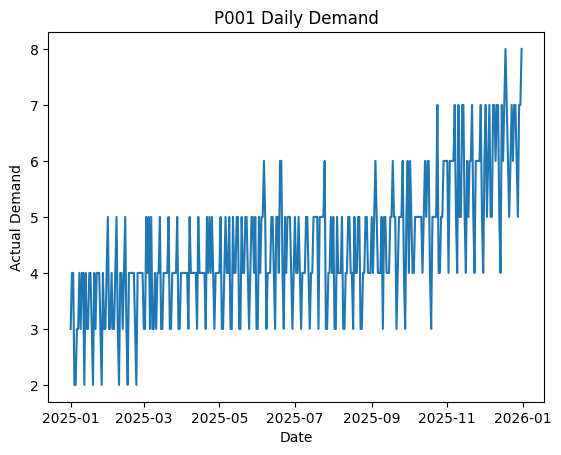

In [67]:
plt.plot(p001_data["date"], p001_data["actual_demand"])

plt.xlabel("Date")
plt.ylabel("Actual Demand")
plt.title("P001 Daily Demand")

plt.show()

### 7-Day Rolling Average

Calculate a 7-day rolling average to smooth daily demand fluctuations and make the underlying demand trend easier to observe.

In [72]:
p001_data["rolling_mean_7d"] = (
    p001_data["actual_demand"]
    .rolling(window=7)
    .mean()
)

In [73]:
p001_data[["actual_demand", "rolling_mean_7d"]].head(10)

,actual_demand,rolling_mean_7d
0,3,NaN
1,4,NaN
2,4,NaN
3,2,NaN
4,2,NaN
5,3,NaN
6,3,3.000000
7,4,3.142857
8,3,3.000000
9,4,3.000000


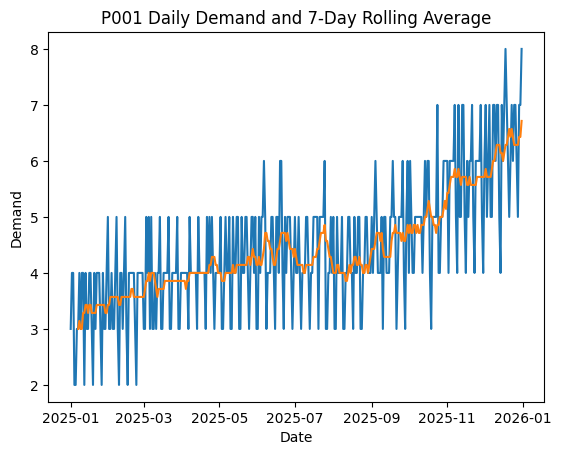

In [74]:
plt.plot(p001_data["date"], p001_data["actual_demand"])
plt.plot(p001_data["date"], p001_data["rolling_mean_7d"])

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("P001 Daily Demand and 7-Day Rolling Average")

plt.show()

## 13. Final Historical Demand Dataset

Prepare the final synthetic historical demand dataset that will be used in the forecasting phase.

Only relevant historical information is retained, while internal factors used to generate the synthetic data are excluded.

In [75]:
historical_demand = product_daily[
    ["date", "product_id", "actual_demand"]
]

In [76]:
historical_demand.head()


,date,product_id,actual_demand
0,2025-01-01,P001,3
1,2025-01-02,P001,4
2,2025-01-03,P001,4
3,2025-01-04,P001,2
4,2025-01-05,P001,2


In [77]:
historical_demand.shape

(3650, 3)

In [78]:
historical_demand.to_csv(
    "../data/historical_demand.csv",
    index=False
)

## 14. Saved Dataset Verification

Reload the saved historical demand dataset to verify that it was exported correctly and can be used independently in future forecasting notebooks.

In [79]:
saved_data = pd.read_csv("../data/historical_demand.csv")

In [80]:
saved_data.shape

(3650, 3)

## Phase 2 Summary

This phase created a synthetic historical demand dataset for the warehouse.

### Key Outcomes

- Generated one year of daily demand data for 10 products.
- Created 3,650 product-day observations.
- Introduced weekly demand patterns.
- Added monthly seasonality and an upward demand trend.
- Added random variation to simulate realistic daily fluctuations.
- Validated the generated data for missing and invalid demand values.
- Visualized daily demand and a 7-day rolling average.
- Created a clean historical dataset containing date, product ID, and actual demand.
- Exported and verified the dataset as `historical_demand.csv`.

This dataset will serve as the historical data foundation for the demand forecasting phase.